# 08 — Definição do Target e Setup para Machine Learning
## Instagram & Bem-Estar: O Custo Psicológico das Redes Sociais
### Laboratório de Análise de Dados — Parte II

**Objectivos deste notebook:**
- Justificar a escolha das variáveis target
- Descrever o objectivo final (regressão e classificação)
- Preparar os dados para todos os modelos seguintes
- Definir as amostras para modelos computacionalmente pesados

In [ ]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor': '#1a1a2e',
    'axes.labelcolor': 'white', 'xtick.color': 'white',
    'ytick.color': 'white', 'text.color': 'white',
    'axes.titlecolor': 'white', 'grid.color': '#2a2a4a',
    'axes.spines.top': False, 'axes.spines.right': False,
})
COLORS = ['#833ab4','#fd1d1d','#fcb045','#405de6','#5851db','#e1306c','#f77737']

os.makedirs('../models', exist_ok=True)
print('Setup completo!')

✅ Setup completo!


In [2]:
# ============================================================
# CARREGAMENTO DO DATASET ENRIQUECIDO
# ============================================================
df = pd.read_csv('../data/instagram_enriched.csv')
print(f'Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f'\nColunas disponíveis:')
for col in df.columns:
    print(f'   • {col:<45} [{df[col].dtype}]')

Dataset carregado: 300,000 linhas × 66 colunas

Colunas disponíveis:
   • user_id                                       [int64]
   • app_name                                      [str]
   • age                                           [int64]
   • gender                                        [str]
   • country                                       [str]
   • urban_rural                                   [str]
   • income_level                                  [str]
   • employment_status                             [str]
   • education_level                               [str]
   • relationship_status                           [str]
   • has_children                                  [str]
   • exercise_hours_per_week                       [float64]
   • sleep_hours_per_night                         [float64]
   • diet_quality                                  [str]
   • smoking                                       [str]
   • alcohol_frequency                             [str]
   • pe

In [ ]:
# ============================================================
# DEFINIÇÃO DAS FEATURES (X)
# ============================================================

# Variáveis de input — comportamento digital e estilo de vida
FEATURES = [
    # Uso do Instagram
    'daily_active_minutes_instagram',
    'sessions_per_day',
    'reels_watched_per_day',
    'stories_viewed_per_day',
    'time_on_feed_per_day',
    'time_on_reels_per_day',
    'posts_created_per_week',
    'likes_given_per_day',
    'average_session_length_minutes',
    'user_engagement_score',
    # Saúde e estilo de vida
    'sleep_hours_per_night',
    'exercise_hours_per_week',
    'daily_steps_count',
    'body_mass_index',
    # Features engineered (Parte I)
    'digital_addiction_score',
    'wellbeing_index',
    'doom_scroll_ratio',
    'follower_ratio',
    # Demográficas numéricas
    'age',
]

# Filtra apenas as que existem no dataset
FEATURES = [f for f in FEATURES if f in df.columns]

print(f' Features seleccionadas: {len(FEATURES)}')
print()
for i, f in enumerate(FEATURES, 1):
    desc = df[f].describe()
    print(f'   {i:>2}. {f:<45} μ={desc["mean"]:>8.2f}  σ={desc["std"]:>8.2f}')

📊 Features seleccionadas: 19

    1. daily_active_minutes_instagram                μ=  188.66  σ=  110.12
    2. sessions_per_day                              μ=   10.36  σ=    7.95
    3. reels_watched_per_day                         μ=  175.80  σ=   76.18
    4. stories_viewed_per_day                        μ=  101.31  σ=   38.76
    5. time_on_feed_per_day                          μ=   94.33  σ=   56.47
    6. time_on_reels_per_day                         μ=   56.63  σ=   35.38
    7. posts_created_per_week                        μ=    5.96  σ=    3.89
    8. likes_given_per_day                           μ=  119.32  σ=   56.13
    9. average_session_length_minutes                μ=   20.51  σ=    8.69
   10. user_engagement_score                         μ=    1.64  σ=    1.80
   11. sleep_hours_per_night                         μ=    7.00  σ=    1.10
   12. exercise_hours_per_week                       μ=    7.15  σ=    3.99
   13. daily_steps_count                             μ= 80

In [4]:
# ============================================================
# JUSTIFICAÇÃO DA SELECÇÃO DE FEATURES
# ============================================================
print('='*65)
print('   📝 JUSTIFICAÇÃO DA SELECÇÃO DE FEATURES')
print('='*65)

justificacao = {
    'daily_active_minutes_instagram': 'Correlação r=0.84 com stress — feature mais preditiva',
    'sessions_per_day':               'Indica compulsividade de acesso',
    'reels_watched_per_day':          'Correlação r=0.68 com stress — conteúdo passivo',
    'time_on_reels_per_day':          'Tempo de consumo passivo (doom-scrolling)',
    'digital_addiction_score':        'Composto de uso criado na Parte I',
    'wellbeing_index':                'Índice de bem-estar criado na Parte I',
    'doom_scroll_ratio':              'Proporção de consumo passivo',
    'sleep_hours_per_night':          'Indicador de saúde directamente afectado pelo uso',
    'exercise_hours_per_week':        'Indicador de estilo de vida activo',
    'age':                            'Factor demográfico com correlação com uso',
}

for feat, just in justificacao.items():
    if feat in FEATURES:
        print(f'   ✅ {feat:<45} → {just}')

print(f'\n   Features excluídas:')
excluidas = ['blood_pressure_systolic', 'blood_pressure_diastolic',
             'last_login_date', 'account_creation_year', 'user_id']
for feat in excluidas:
    print(f'   ❌ {feat:<45} → Irrelevante ou identificador')


   📝 JUSTIFICAÇÃO DA SELECÇÃO DE FEATURES
   ✅ daily_active_minutes_instagram                → Correlação r=0.84 com stress — feature mais preditiva
   ✅ sessions_per_day                              → Indica compulsividade de acesso
   ✅ reels_watched_per_day                         → Correlação r=0.68 com stress — conteúdo passivo
   ✅ time_on_reels_per_day                         → Tempo de consumo passivo (doom-scrolling)
   ✅ digital_addiction_score                       → Composto de uso criado na Parte I
   ✅ wellbeing_index                               → Índice de bem-estar criado na Parte I
   ✅ doom_scroll_ratio                             → Proporção de consumo passivo
   ✅ sleep_hours_per_night                         → Indicador de saúde directamente afectado pelo uso
   ✅ exercise_hours_per_week                       → Indicador de estilo de vida activo
   ✅ age                                           → Factor demográfico com correlação com uso

   Features excluídas:


In [5]:
# ============================================================
# TARGET 1 — REGRESSÃO: perceived_stress_score
# ============================================================
TARGET_REG = 'perceived_stress_score'

print('='*65)
print('   🎯 TARGET 1 — REGRESSÃO')
print('='*65)
print(f'  Variável     : {TARGET_REG}')
print(f'  Tipo         : Quantitativa Contínua')
print(f'  Escala       : 0 a 40')
print(f'  Média        : {df[TARGET_REG].mean():.3f}')
print(f'  Mediana      : {df[TARGET_REG].median():.3f}')
print(f'  Desv. Padrão : {df[TARGET_REG].std():.3f}')
print(f'  Mínimo       : {df[TARGET_REG].min():.3f}')
print(f'  Máximo       : {df[TARGET_REG].max():.3f}')
print()
print('  OBJECTIVO: Prever o nível de stress percepcionado')
print('  de um utilizador com base no seu comportamento digital')
print('  e indicadores de saúde.')
print()
print('  APLICAÇÃO PRÁTICA: Um profissional de saúde pode inserir')
print('  os hábitos digitais de um paciente e obter uma estimativa')
print('  do seu nível de stress para triagem de risco.')
print()
print('  JUSTIFICAÇÃO DA ESCOLHA:')
print('  • r = 0.84 com daily_active_minutes_instagram')
print('  • Resultado central da Parte I')
print('  • Alta variabilidade — adequado para regressão')
print('  • Relevância clínica e social clara')

   🎯 TARGET 1 — REGRESSÃO
  Variável     : perceived_stress_score
  Tipo         : Quantitativa Contínua
  Escala       : 0 a 40
  Média        : 20.020
  Mediana      : 20.000
  Desv. Padrão : 11.829
  Mínimo       : 0.000
  Máximo       : 40.000

  OBJECTIVO: Prever o nível de stress percepcionado
  de um utilizador com base no seu comportamento digital
  e indicadores de saúde.

  APLICAÇÃO PRÁTICA: Um profissional de saúde pode inserir
  os hábitos digitais de um paciente e obter uma estimativa
  do seu nível de stress para triagem de risco.

  JUSTIFICAÇÃO DA ESCOLHA:
  • r = 0.84 com daily_active_minutes_instagram
  • Resultado central da Parte I
  • Alta variabilidade — adequado para regressão
  • Relevância clínica e social clara


In [6]:
# ============================================================
# TARGET 2 — CLASSIFICAÇÃO: user_persona
# ============================================================
TARGET_CLF = 'user_persona'

print('='*65)
print('   🎯 TARGET 2 — CLASSIFICAÇÃO')
print('='*65)
print(f'  Variável   : {TARGET_CLF}')
print(f'  Tipo       : Qualitativa Nominal (5 classes)')
print()

# Distribuição das classes
dist = df[TARGET_CLF].value_counts()
print(f'  Distribuição das classes:')
for persona, count in dist.items():
    pct  = count / len(df) * 100
    bar  = '█' * int(pct / 2)
    print(f'    {persona:<25} : {count:>7,} ({pct:>5.1f}%) {bar}')

print()
print('  OBJECTIVO: Classificar o tipo de utilizador (persona)')
print('  com base nos seus hábitos digitais e de saúde.')
print()
print('  APLICAÇÃO PRÁTICA: Segmentação automática de utilizadores')
print('  para personalização de conteúdo, intervenções de saúde')
print('  digital e estratégias de marketing.')
print()
print('  JUSTIFICAÇÃO DA ESCOLHA:')
print('  • 5 classes equilibradas e semanticamente distintas')
print('  • Criada com base em padrões identificados na Parte I')
print('  • Útil para todos os 4 dashboards existentes')

   🎯 TARGET 2 — CLASSIFICAÇÃO
  Variável   : user_persona
  Tipo       : Qualitativa Nominal (5 classes)

  Distribuição das classes:
    Influencer/Creator        : 142,363 ( 47.5%) ███████████████████████
    Utilizador Casual         : 110,559 ( 36.9%) ██████████████████
    Social Poster             :  36,560 ( 12.2%) ██████
    Silent Browser            :   9,625 (  3.2%) █
    Doom-Scroller             :     893 (  0.3%) 

  OBJECTIVO: Classificar o tipo de utilizador (persona)
  com base nos seus hábitos digitais e de saúde.

  APLICAÇÃO PRÁTICA: Segmentação automática de utilizadores
  para personalização de conteúdo, intervenções de saúde
  digital e estratégias de marketing.

  JUSTIFICAÇÃO DA ESCOLHA:
  • 5 classes equilibradas e semanticamente distintas
  • Criada com base em padrões identificados na Parte I
  • Útil para todos os 4 dashboards existentes


In [7]:
# ============================================================
# PREPARAÇÃO DOS DADOS
# ============================================================

# Remove linhas com NaN nas features ou targets
cols_needed = FEATURES + [TARGET_REG, TARGET_CLF]
df_clean = df[cols_needed].dropna().reset_index(drop=True)

print(f'✅ Linhas antes da limpeza : {len(df):>10,}')
print(f'✅ Linhas após limpeza     : {len(df_clean):>10,}')
print(f'   Removidas (NaN)         : {len(df)-len(df_clean):>10,}')

# Encode do target de classificação
le = LabelEncoder()
df_clean['user_persona_encoded'] = le.fit_transform(df_clean[TARGET_CLF])

print(f'\n📊 Mapeamento de classes:')
for i, cls in enumerate(le.classes_):
    print(f'   {i} → {cls}')

# Guarda o encoder para usar no dashboard
joblib.dump(le, '../models/label_encoder_persona.pkl')
print('\n💾 LabelEncoder guardado: models/label_encoder_persona.pkl')

✅ Linhas antes da limpeza :    300,000
✅ Linhas após limpeza     :    300,000
   Removidas (NaN)         :          0

📊 Mapeamento de classes:
   0 → Doom-Scroller
   1 → Influencer/Creator
   2 → Silent Browser
   3 → Social Poster
   4 → Utilizador Casual

💾 LabelEncoder guardado: models/label_encoder_persona.pkl


In [8]:
# ============================================================
# DEFINIÇÃO DE AMOSTRAS
# ============================================================
print('='*65)
print('   📊 ESTRATÉGIA DE AMOSTRAGEM')
print('='*65)

SAMPLES = {
    'FULL':   50_000,   # modelos rápidos
    'SVM':    10_000,   # SVM é O(n²-n³)
    'KNN':    20_000,   # KNN é O(n) por query
    'HIER':    2_000,   # clustering hierárquico é O(n²)
    'CV':     30_000,   # cross-validation
    'NN':     30_000,   # redes neuronais
}

for name, n in SAMPLES.items():
    print(f'   {name:<8}: {n:>7,} linhas  ({n/len(df_clean)*100:.1f}% do total)')

print(f'\n   Total disponível: {len(df_clean):,} linhas')
print()
print('   JUSTIFICAÇÃO:')
print('   • SVM: complexidade O(n²) a O(n³) — dias com 273k linhas')
print('   • Clustering hierárquico: O(n²) em memória — impraticável')
print('   • Amostras estratificadas garantem representatividade')
print('   • Prática standard em ML com datasets de grande escala')

# Guarda as constantes para uso nos outros notebooks
import json
config = {'FEATURES': FEATURES, 'TARGET_REG': TARGET_REG,
          'TARGET_CLF': TARGET_CLF, 'SAMPLES': SAMPLES}
with open('../models/ml_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('\n💾 Configuração guardada: models/ml_config.json')


   📊 ESTRATÉGIA DE AMOSTRAGEM
   FULL    :  50,000 linhas  (16.7% do total)
   SVM     :  10,000 linhas  (3.3% do total)
   KNN     :  20,000 linhas  (6.7% do total)
   HIER    :   2,000 linhas  (0.7% do total)
   CV      :  30,000 linhas  (10.0% do total)
   NN      :  30,000 linhas  (10.0% do total)

   Total disponível: 300,000 linhas

   JUSTIFICAÇÃO:
   • SVM: complexidade O(n²) a O(n³) — dias com 273k linhas
   • Clustering hierárquico: O(n²) em memória — impraticável
   • Amostras estratificadas garantem representatividade
   • Prática standard em ML com datasets de grande escala

💾 Configuração guardada: models/ml_config.json


In [9]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

# Amostra principal para a maioria dos modelos
df_sample = df_clean.sample(n=SAMPLES['FULL'], random_state=42).reset_index(drop=True)

X = df_sample[FEATURES].values
y_reg = df_sample[TARGET_REG].values
y_clf = df_sample['user_persona_encoded'].values

# Split 80/20
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

print(f'📊 SPLIT 80/20:')
print(f'   Total na amostra : {len(df_sample):>8,}')
print(f'   Treino           : {len(X_train):>8,} ({len(X_train)/len(df_sample)*100:.0f}%)')
print(f'   Teste            : {len(X_test):>8,} ({len(X_test)/len(df_sample)*100:.0f}%)')
print(f'   Features (X)     : {X_train.shape[1]:>8}')
print()
print(f'   Target Regressão (treino) — μ={y_train_reg.mean():.2f}, σ={y_train_reg.std():.2f}')
print(f'   Target Regressão (teste)  — μ={y_test_reg.mean():.2f}, σ={y_test_reg.std():.2f}')

📊 SPLIT 80/20:
   Total na amostra :   50,000
   Treino           :   40,000 (80%)
   Teste            :   10,000 (20%)
   Features (X)     :       19

   Target Regressão (treino) — μ=19.95, σ=11.81
   Target Regressão (teste)  — μ=20.16, σ=11.89


In [10]:
# ============================================================
# NORMALIZAÇÃO DAS FEATURES
# ============================================================

# StandardScaler para modelos sensíveis à escala (SVM, KNN, NN)
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std  = scaler_std.transform(X_test)

# MinMaxScaler para modelos baseados em distâncias
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm  = scaler_mm.transform(X_test)

# Guarda os scalers
joblib.dump(scaler_std, '../models/scaler_standard.pkl')
joblib.dump(scaler_mm,  '../models/scaler_minmax.pkl')

print('✅ Scalers aplicados e guardados:')
print(f'   StandardScaler — X_train: μ≈{X_train_std.mean():.4f}, σ≈{X_train_std.std():.4f}')
print(f'   MinMaxScaler   — X_train: min={X_train_mm.min():.4f}, max={X_train_mm.max():.4f}')
print()
print('   Quando usar cada scaler:')
scalers_guide = [
    ('StandardScaler', ['SVM', 'KNN', 'Neural Networks', 'Logistic Regression', 'Ridge', 'Lasso']),
    ('MinMaxScaler',   ['K-Means', 'KNN (alternativa)', 'Neural Networks (alternativa)']),
    ('Nenhum',         ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'Naïve Bayes']),
]
for name, models in scalers_guide:
    print(f'   {name:<18}: {", ".join(models)}')

✅ Scalers aplicados e guardados:
   StandardScaler — X_train: μ≈0.0000, σ≈1.0000
   MinMaxScaler   — X_train: min=0.0000, max=1.0000

   Quando usar cada scaler:
   StandardScaler    : SVM, KNN, Neural Networks, Logistic Regression, Ridge, Lasso
   MinMaxScaler      : K-Means, KNN (alternativa), Neural Networks (alternativa)
   Nenhum            : Decision Tree, Random Forest, Gradient Boosting, Naïve Bayes


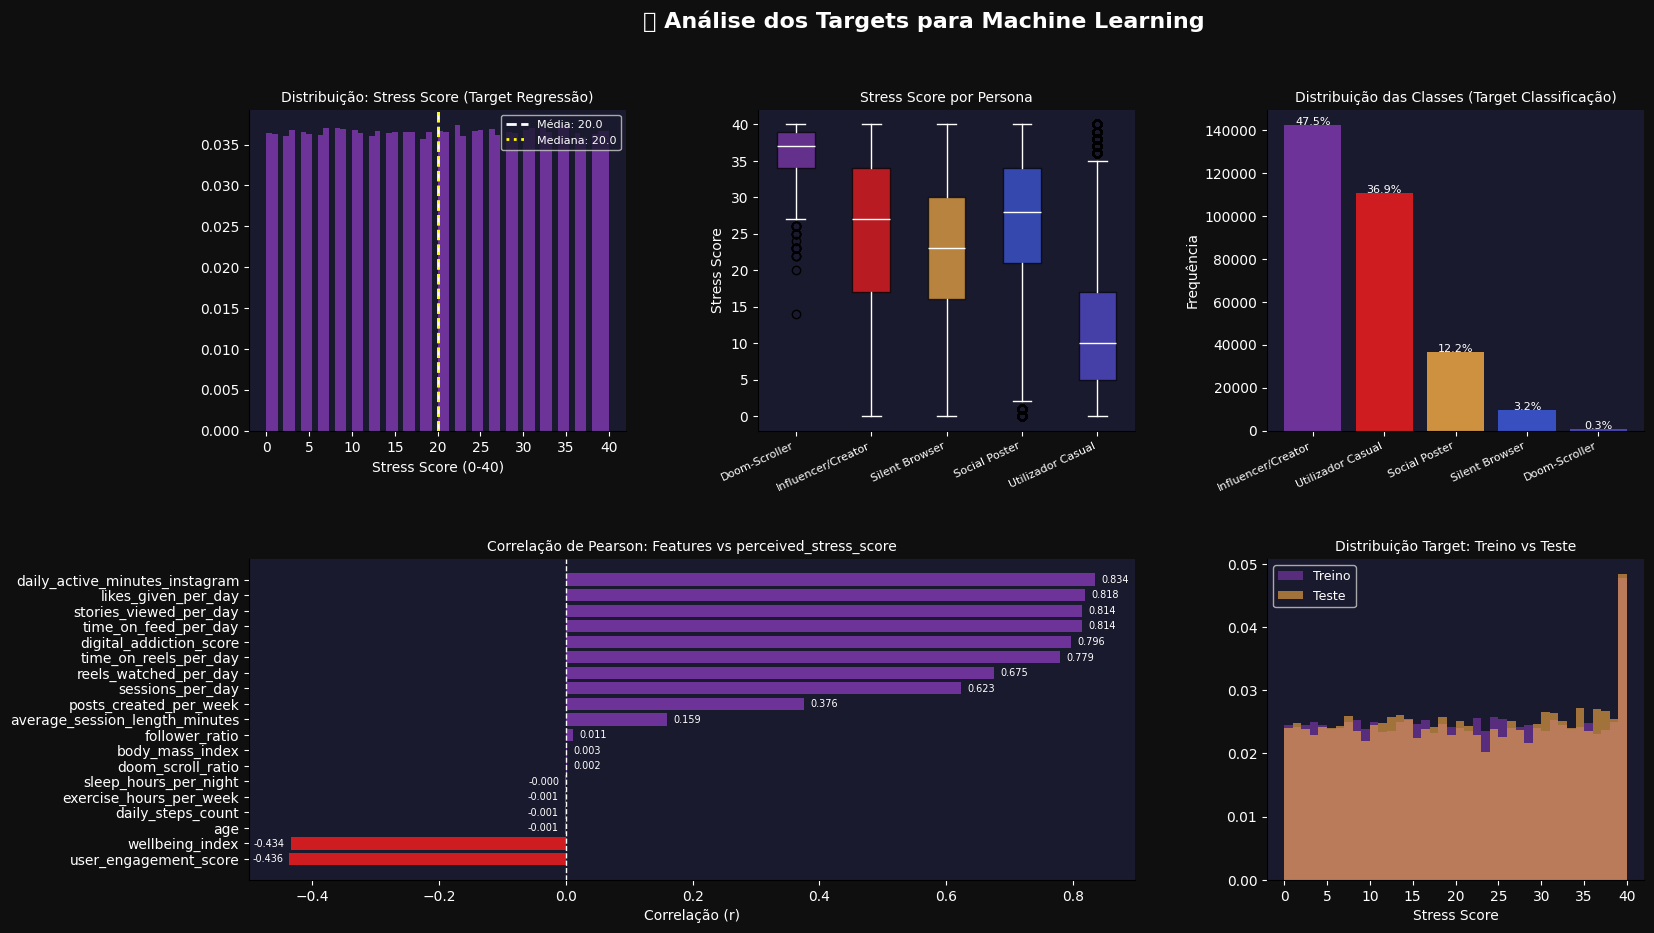

💾 Guardado: fig_ml_setup.png


In [11]:
# ============================================================
# ANÁLISE VISUAL DOS TARGETS
# ============================================================

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('🎯 Análise dos Targets para Machine Learning', fontsize=16, fontweight='bold')

# ── 1. Distribuição do target de regressão
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_clean[TARGET_REG], bins=60, color=COLORS[0], alpha=0.8, density=True, edgecolor='none')
ax1.axvline(df_clean[TARGET_REG].mean(),   color='white',  ls='--', lw=2, label=f'Média: {df_clean[TARGET_REG].mean():.1f}')
ax1.axvline(df_clean[TARGET_REG].median(), color='yellow', ls=':',  lw=2, label=f'Mediana: {df_clean[TARGET_REG].median():.1f}')
ax1.set_title('Distribuição: Stress Score (Target Regressão)', fontsize=10)
ax1.set_xlabel('Stress Score (0-40)')
ax1.legend(fontsize=8)

# ── 2. Boxplot stress por persona
ax2 = fig.add_subplot(gs[0, 1])
personas = df_clean[TARGET_CLF].unique()
data_box = [df_clean[df_clean[TARGET_CLF] == p][TARGET_REG].values for p in sorted(personas)]
bp = ax2.boxplot(data_box, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for elem in ['whiskers','caps','medians','fliers']:
    for item in bp[elem]: item.set_color('white')
ax2.set_xticks(range(1, len(personas)+1))
ax2.set_xticklabels(sorted(personas), rotation=25, ha='right', fontsize=8)
ax2.set_title('Stress Score por Persona', fontsize=10)
ax2.set_ylabel('Stress Score')

# ── 3. Distribuição das classes (target classificação)
ax3 = fig.add_subplot(gs[0, 2])
counts = df_clean[TARGET_CLF].value_counts()
bars = ax3.bar(range(len(counts)), counts.values, color=COLORS[:len(counts)], alpha=0.8)
ax3.set_xticks(range(len(counts)))
ax3.set_xticklabels(counts.index, rotation=25, ha='right', fontsize=8)
ax3.set_title('Distribuição das Classes (Target Classificação)', fontsize=10)
ax3.set_ylabel('Frequência')
for bar, val in zip(bars, counts.values):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f'{val/len(df_clean)*100:.1f}%', ha='center', color='white', fontsize=8)

# ── 4. Correlação features vs target regressão
ax4 = fig.add_subplot(gs[1, :2])
corrs = df_clean[FEATURES + [TARGET_REG]].corr()[TARGET_REG].drop(TARGET_REG).sort_values()
colors_corr = [COLORS[1] if v < 0 else COLORS[0] for v in corrs.values]
bars2 = ax4.barh(corrs.index, corrs.values, color=colors_corr, alpha=0.8)
ax4.axvline(0, color='white', lw=1, ls='--')
ax4.set_title(f'Correlação de Pearson: Features vs {TARGET_REG}', fontsize=10)
ax4.set_xlabel('Correlação (r)')
for bar, val in zip(bars2, corrs.values):
    ax4.text(val + (0.01 if val >= 0 else -0.01),
             bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val>=0 else 'right',
             color='white', fontsize=7)

# ── 5. Treino vs Teste — distribuição do target
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(y_train_reg, bins=40, color=COLORS[0], alpha=0.6, density=True, label='Treino')
ax5.hist(y_test_reg,  bins=40, color=COLORS[2], alpha=0.6, density=True, label='Teste')
ax5.set_title('Distribuição Target: Treino vs Teste', fontsize=10)
ax5.set_xlabel('Stress Score')
ax5.legend(fontsize=9)

plt.savefig('../data/fig_ml_setup.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('💾 Guardado: fig_ml_setup.png')

In [12]:
# ============================================================
# GUARDAR DADOS PREPARADOS PARA NOTEBOOKS SEGUINTES
# ============================================================

np.save('../models/X_train.npy',       X_train)
np.save('../models/X_test.npy',        X_test)
np.save('../models/X_train_std.npy',   X_train_std)
np.save('../models/X_test_std.npy',    X_test_std)
np.save('../models/X_train_mm.npy',    X_train_mm)
np.save('../models/X_test_mm.npy',     X_test_mm)
np.save('../models/y_train_reg.npy',   y_train_reg)
np.save('../models/y_test_reg.npy',    y_test_reg)
np.save('../models/y_train_clf.npy',   y_train_clf)
np.save('../models/y_test_clf.npy',    y_test_clf)

# Guarda feature names
import json
with open('../models/feature_names.json', 'w') as f:
    json.dump(FEATURES, f)

print('💾 Ficheiros guardados em models/:')
files = {
    'X_train.npy':       X_train.shape,
    'X_test.npy':        X_test.shape,
    'X_train_std.npy':   X_train_std.shape,
    'X_test_std.npy':    X_test_std.shape,
    'y_train_reg.npy':   y_train_reg.shape,
    'y_test_reg.npy':    y_test_reg.shape,
    'y_train_clf.npy':   y_train_clf.shape,
    'y_test_clf.npy':    y_test_clf.shape,
}
for fname, shape in files.items():
    print(f'   ✅ {fname:<30} shape: {shape}')

print(f'\n✅ Notebook 08 completo!')
print(f'   Próximo: 09_regression_models.ipynb')

💾 Ficheiros guardados em models/:
   ✅ X_train.npy                    shape: (40000, 19)
   ✅ X_test.npy                     shape: (10000, 19)
   ✅ X_train_std.npy                shape: (40000, 19)
   ✅ X_test_std.npy                 shape: (10000, 19)
   ✅ y_train_reg.npy                shape: (40000,)
   ✅ y_test_reg.npy                 shape: (10000,)
   ✅ y_train_clf.npy                shape: (40000,)
   ✅ y_test_clf.npy                 shape: (10000,)

✅ Notebook 08 completo!
   Próximo: 09_regression_models.ipynb


In [13]:
# ============================================================
# RESUMO FINAL DO SETUP
# ============================================================

print('='*65)
print('   📋 RESUMO DO SETUP DE MACHINE LEARNING')
print('='*65)
print()
print(f'  DATASET:')
print(f'   Total de linhas disponíveis : {len(df_clean):>10,}')
print(f'   Amostra principal (FULL)    : {SAMPLES["FULL"]:>10,}')
print(f'   Features (X)                : {len(FEATURES):>10}')
print()
print(f'  PROBLEMA 1 — REGRESSÃO:')
print(f'   Target    : {TARGET_REG}')
print(f'   Objectivo : Prever o nível de stress (0-40)')
print(f'   Modelos   : Linear Reg, Ridge, Lasso, SVM, KNN,')
print(f'               Random Forest, Neural Network')
print()
print(f'  PROBLEMA 2 — CLASSIFICAÇÃO:')
print(f'   Target    : {TARGET_CLF} (5 classes)')
print(f'   Objectivo : Classificar a persona do utilizador')
print(f'   Modelos   : Logistic Reg, Naïve Bayes, SVM, KNN,')
print(f'               Decision Tree, Random Forest, Neural Network')
print()
print(f'  AMOSTRAS ESPECIAIS:')
for k, v in SAMPLES.items():
    print(f'   {k:<8}: {v:>7,} linhas')
print()
print('  FICHEIROS GERADOS:')
ficheiros = ['models/X_train.npy', 'models/X_test.npy',
             'models/X_train_std.npy', 'models/X_test_std.npy',
             'models/y_train_reg.npy', 'models/y_test_reg.npy',
             'models/y_train_clf.npy', 'models/y_test_clf.npy',
             'models/scaler_standard.pkl', 'models/scaler_minmax.pkl',
             'models/label_encoder_persona.pkl',
             'models/ml_config.json', 'models/feature_names.json',
             'data/fig_ml_setup.png']
for f in ficheiros:
    print(f'   ✅ {f}')

   📋 RESUMO DO SETUP DE MACHINE LEARNING

  DATASET:
   Total de linhas disponíveis :    300,000
   Amostra principal (FULL)    :     50,000
   Features (X)                :         19

  PROBLEMA 1 — REGRESSÃO:
   Target    : perceived_stress_score
   Objectivo : Prever o nível de stress (0-40)
   Modelos   : Linear Reg, Ridge, Lasso, SVM, KNN,
               Random Forest, Neural Network

  PROBLEMA 2 — CLASSIFICAÇÃO:
   Target    : user_persona (5 classes)
   Objectivo : Classificar a persona do utilizador
   Modelos   : Logistic Reg, Naïve Bayes, SVM, KNN,
               Decision Tree, Random Forest, Neural Network

  AMOSTRAS ESPECIAIS:
   FULL    :  50,000 linhas
   SVM     :  10,000 linhas
   KNN     :  20,000 linhas
   HIER    :   2,000 linhas
   CV      :  30,000 linhas
   NN      :  30,000 linhas

  FICHEIROS GERADOS:
   ✅ models/X_train.npy
   ✅ models/X_test.npy
   ✅ models/X_train_std.npy
   ✅ models/X_test_std.npy
   ✅ models/y_train_reg.npy
   ✅ models/y_test_reg.npy
   